# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [156]:
ПІБ = 'Бугай Софія'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 2     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [157]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 2 · Бугай Софія, ШІ-34, «Longer Boats»
Підприємство «Longer Boats» виготовляє яхти. Одиниця виміру плану: шт./місяць.

                       Sting  Ray  Breaker  Marlin  ЗАПАС
Склопластик, м²            4    2        5       2   1271
Столярний цех, год         6    5        4       2    702
Фарбувальний цех, год      5    2        0       3    915
Такелаж, компл.            2    1        5       0   1388
Ділянка добудови, год      5    5        6       2    804

                    Sting  Ray  Breaker  Marlin
Прибуток з одиниці     40   66       24      34

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Столярний цех, год
  ціна:   16.7 за одиницю
  обсяг:  до 204 одиниць


In [158]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1, x2, x3 ,x4 - кількості яхт відповідно String, Ray, Breaker та Marlin

Цільова функція: `40·x1 + 66·x2 + 24·x3 + 34·x4 → max`

Обмеження:
* `4·x1 + 2·x2 + 5·x3 + 2·x4 ≤ 1271`
* `6·x1 + 5·x2 + 4·x3 + 2·x4 ≤ 702`
* `5·x1 + 2·x2 + 0·x3 + 3·x4 ≤ 915`
* `2·x1 + 1·x2 + 5·x3 + 0·x4 ≤ 1388`
* `5·x1 + 5·x2 + 6·x3 + 2·x4 ≤ 804`

Невід'ємність:
* `x1 ≥ 0`
* `x2 ≥ 0`
* `x3 ≥ 0`
* `x4 ≥ 0`


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** Запас ресурсу - це параметр, а не змінна рішення, бо зараз нам не дозволено ними керувати - вони слугують обмеженням матеріалів та не докуповуються просто так. Якби підприємство могло докупити ресурс, потрібно було би враховувати ціну ресурсу, тобто утворюються 5 нових змінних (наприклад, у-ки), які ітимуть в цільову функцію з від'ємними знаками.

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

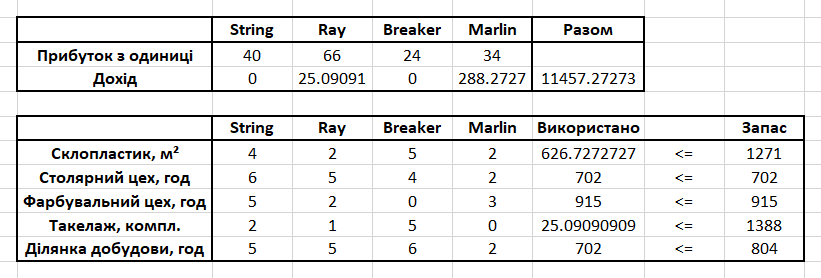

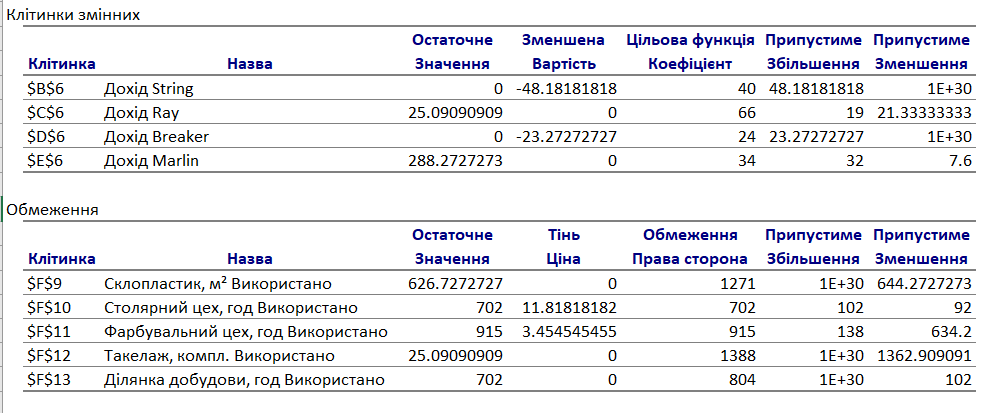
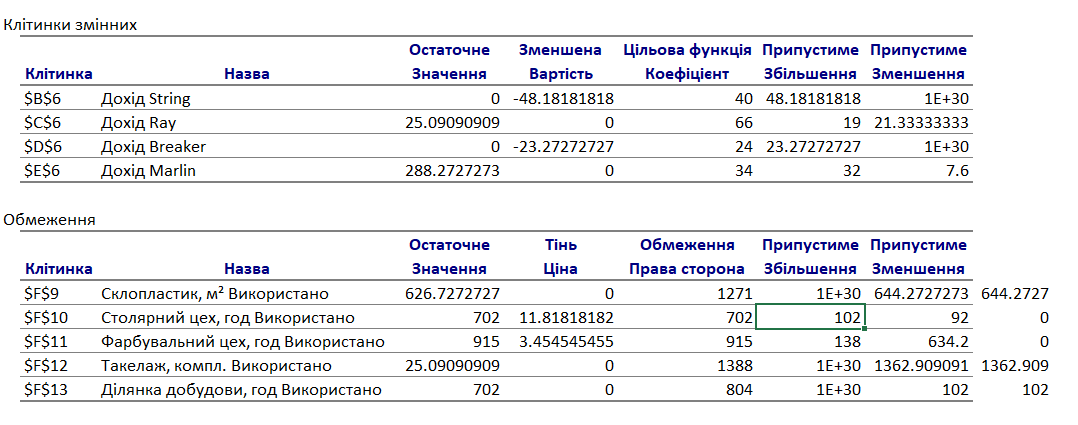
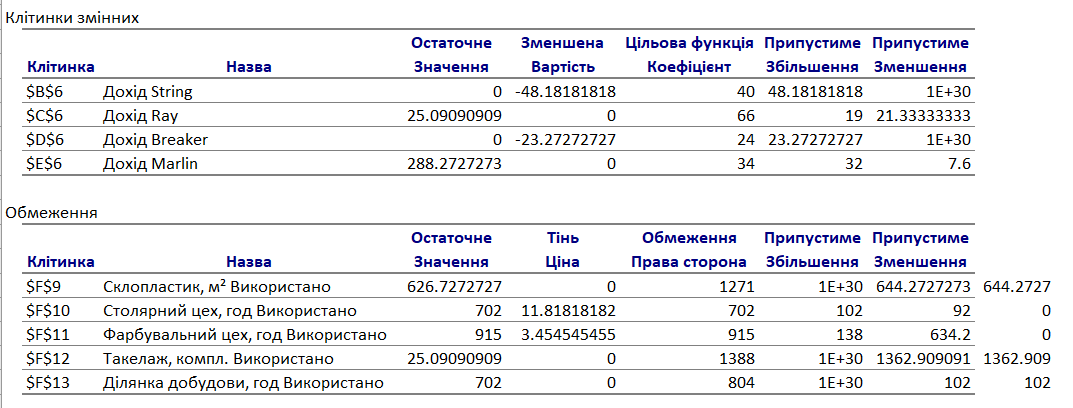
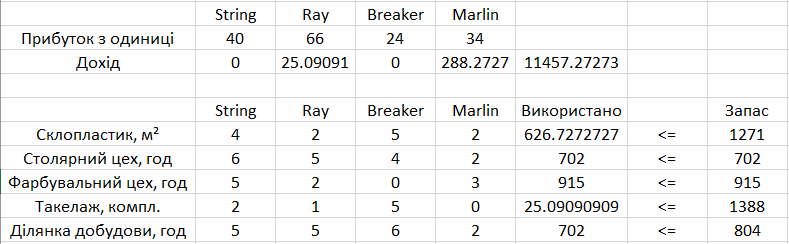

In [159]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0, 25.09091, 0, 288.2727]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 11457.027273            # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 25.09091, 0, 288.2727] | прибуток 11457.027273


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [160]:
# ВАШ КОД
from scipy.optimize import linprog
c = [-40, -66, -24, -34]
A = [[4, 2, 5, 2],
     [6, 5, 4, 2],
     [5, 2, 0, 3],
     [2, 1, 5, 0],
     [5, 5, 6, 2]]
b = [1271, 702, 915, 1388, 804]
res = linprog(c,  A_ub=A, b_ub=b)
план = res.x
прибуток = -res.fun
print(план, прибуток)

[  0.          25.09090909   0.         288.27272727] 11457.272727272726


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [161]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Склопластик | 626.727 | 0 | 1271 | 1Е+30 | 644.273 |
| Столярний цех | 702 | 11.818 | 702 | 102 | 92 |
| Фарбувальний цех | 915 | 3.455 | 915 | 138 | 634.2 |
| Такелаж | 25.091 | 0 | 1388 | 1Е+30 | 1362.909 |
| Ділянка добудови | 702 | 0 | 804 | 1Е+30 | 102 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**
У надлишку склопластик, такелаж та ділянка добудови. Визначила це через різницю стовпця "Обмеження Права сторона" та "Остаточне Значення". Якщо значення > 0, то матеріал у надлишку, інакше - у дефіциті. Звідси - столярний та фарбувальний цехи у дефіциті.

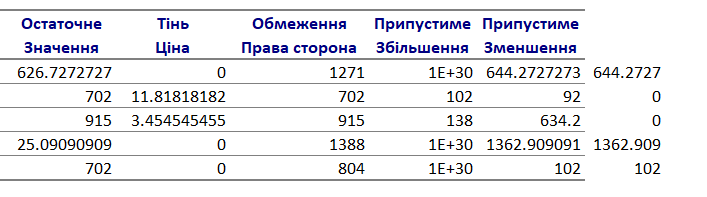


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| String | 0 | -48.182 | 40 | 48.182 | 1E+30 |
| Ray | 25.091 | 0 | 66 | 19 | 21.333 |
| Breaker | 0 | -23.273 | 24 | 23.273 | 1E+30 |
| Marlin | 288.273 | 0 | 34 | 32 | 7.6 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число? 

String та Breaker зовсім не вироблялись. Щоб вони вироблялись, дохід String варто було б збільшити на більше, ніж 48.18, а для Breacker - більше, ніж 23.27. Надані значення були взяти зі стовпця "Припустиме Збільшення", де збільшення ціни на надане значення чи менше не впливає на виробничий процес, тобто при збільшення ціни хоча б на 0.01 змінить кількість вироблення наданих виробів.


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [162]:
# ВАШ КОД
# Найдорожчий - Столярний цех (1)
b_new = b.copy()
b_new[1] += 1
res_2 = linprog(c,  A_ub=A, b_ub=b_new)
new_прибуток = -res_2.fun
print(f'{new_прибуток} - {прибуток} = {new_прибуток - прибуток} = 11.8181')

11469.09090909091 - 11457.272727272726 = 11.818181818183803 = 11.8181


**Відповідь 5.1:** Тіньова ціна столярного цеху - 11.818181. 

11469.0909 - 11.457.2727 = 11.8181. 

Так, вони збігаються.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

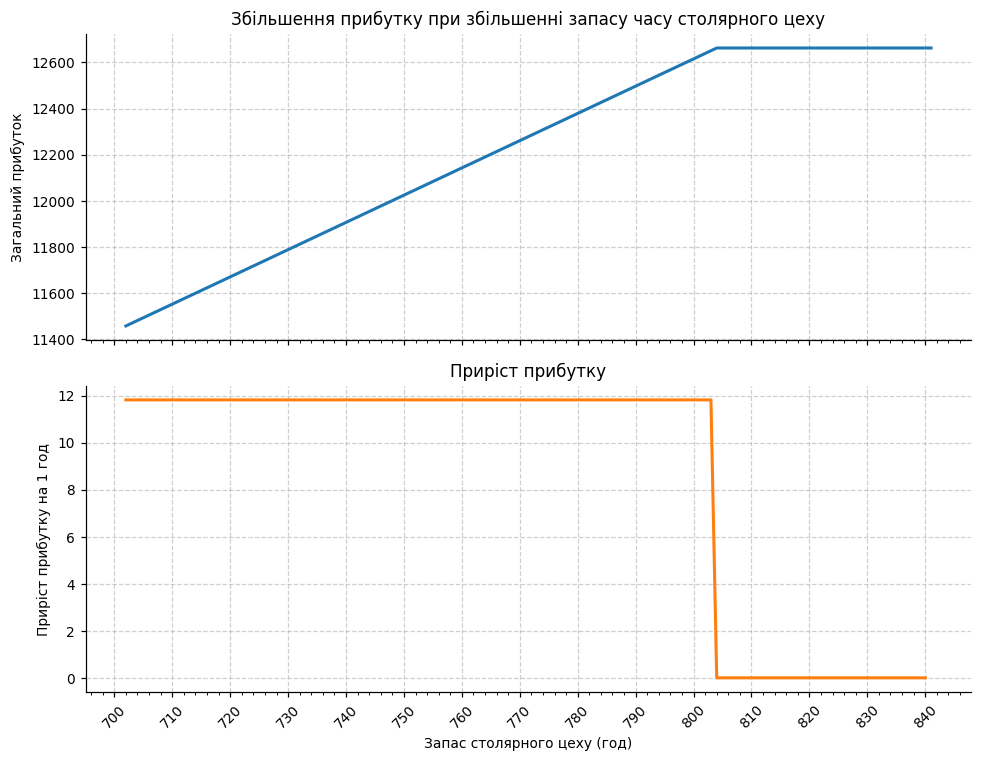

In [163]:
# ВАШ КОД
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

n_steps = 140
b_big = np.full((n_steps, 5), b, dtype=float)
b_long = np.arange(n_steps)
b_big[:, 1] += b_long

x_resource = b[1] + b_long

profit = [-(linprog(c, A_ub=A, b_ub=b_big[i])).fun for i in range(n_steps)]

slope = np.diff(profit)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.plot(x_resource, profit, color='tab:blue', linewidth=2)
ax1.set_title('Збільшення прибутку при збільшенні запасу часу столярного цеху', fontsize=11)
ax1.set_ylabel('Загальний прибуток')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(x_resource[:-1], slope, color='tab:orange', linewidth=2)
ax2.set_title('Приріст прибутку', fontsize=11)
ax2.set_xlabel('Запас столярного цеху (год)')
ax2.set_ylabel('Приріст прибутку на 1 год')
ax2.grid(True, linestyle='--', alpha=0.6)

ax2.xaxis.set_major_locator(MultipleLocator(10))
ax2.xaxis.set_minor_locator(MultipleLocator(2))

ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Відповідь 5.2:** Запас можна збільшити ~ на 102 одиниці (початкове значення 702, кінцеве - ~804). Надане значення збігається з комінкою "Допустиме Збільшення" столярного цеху у Excel (102).

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [164]:
# ВАШ КОД
# столярний цех, 16.7, 204
price = 16.7
bought_num = 204
b_check = b.copy()
b_check[1] += bought_num

ans = linprog(c,  A_ub=A, b_ub=b_check)
print("Прибуток за пропозиції :", res.fun-ans.fun)
print("З урахуванням витрат на закупівлю :", res.fun-ans.fun-price*bought_num)


Прибуток за пропозиції : 1205.4545454545478
З урахуванням витрат на закупівлю : -2201.345454545452


**Відповідь 6.1:**

* Брати чи ні і чому: Ні. Ціна 16.7 вища за тіньову ціну в 11.81 та стане зитком при купівлі.
* Скільки одиниць має сенс купити і чому не більше: Якщо ціна була би менша чи рівна тіньовій (11.81), брати варто 102 одиниці, це збільшик прибуток на максимум.
* Очікуваний виграш: Збитковість через витрати рівні (16.7-11.81)⋅102 + 16.7⋅(204-102) ≈ 2.202.18
* Перевірка прямим розв'язанням дала: Виграш від виробництва рівний 1205.45, однак з урахуванням витрат на докупи збитковість рівна -2201.35


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [165]:
# ВАШ КОД
ненульових = int(np.sum(res.x > 0))
звязних = int(np.sum(np.isclose(res.slack, 0, atol=1e-5)))

In [166]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** Числа збіглися. У іншому випадку, задача була би вироджена.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [167]:
# ВАШ КОД
rounded = np.array([0, 25, 0, 288])
is_rounded_acc = np.matmul(A, rounded) <= b
if False in is_rounded_acc:
    print("Округлений план не є допустимим")
else :
    print("Округлений план допустимий")
print("Прибуток округленого плану :", -np.matmul(c, rounded))

int_res = linprog(c,  A_ub=A, b_ub=b, integrality=1)

print("План цілочисельного плану :", int_res.x)
print("Прибуток цілочисельного плану :", -int_res.fun)

Округлений план допустимий
Прибуток округленого плану : 11442
План цілочисельного плану : [  0.  25.   0. 288.]
Прибуток цілочисельного плану : 11442.0


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | 0, 25.0909, 0, 288.2727 | 11457.2727 | Так |
| округлений | 0, 25, 0, 288 | 11442 | Так |
| цілочисельний оптимум | 0, 25, 0, 288 | 11442 | Так |

**Висновок:** У даному випадку заокруглювати можна, бо ми заокруглюємо донизу - ми втрачаємо частину прибутку, однак не виходимо за обмеження. При заокругленні догори варто перевіряти обмеження.


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [168]:
# ВАШ КОД — впишіть свої дані
постачальники = ["Бровари", "Ужгород", "Городок"]     
споживачі     = ["Слов'янськ", "Одеса", "Фудзімі", "Ізюм"]     
D = np.array([[662, 495, 11991, 612],
              [1482, 1022, 12616, 1432],
              [1238, 851, 12376, 1188]])  
запас = [3, 8, 5]  
попит = [4, 6, 3, 3] 

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Слов'янськ,Одеса,Фудзімі,Ізюм
Бровари,662,495,11991,612
Ужгород,1482,1022,12616,1432
Городок,1238,851,12376,1188


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [169]:
# ВАШ КОД — розв'язок 1
n_suppliers = len(постачальники)
n_consumers = len(споживачі)
c = D.flatten()

A_eq = []
b_eq = []

for i in range(n_suppliers):
  row = np.zeros(n_suppliers * n_consumers)
  row[i * n_consumers : (i + 1) * n_consumers] = 1
  A_eq.append(row)
  b_eq.append(запас[i])

for j in range(n_consumers):
  row = np.zeros(n_suppliers * n_consumers)
  for i in range(n_suppliers):
    row[i * n_consumers + j] = 1
  A_eq.append(row)
  b_eq.append(попит[j])

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')

X_plan = pd.DataFrame(
    res.x.reshape((n_suppliers, n_consumers)),
    index=постачальники,
    columns=споживачі,
)

print(f'Сумарна вартість : {res.fun}')
display(X_plan)

тіньові_ціни_1 = pd.DataFrame({"Тіньова ціна": res.eqlin.marginals},
                       index=[f"Запас: {p}" for p in постачальники] +
                             [f"Попит: {s}" for s in споживачі]) 
display(тіньові_ціни_1) 

Сумарна вартість : 50528.0


,Слов'янськ,Одеса,Фудзімі,Ізюм
Бровари,0.0,0.0,0.0,3.0
Ужгород,0.0,6.0,2.0,0.0
Городок,4.0,0.0,1.0,-0.0


,Тіньова ціна
Запас: Бровари,-0.0
Запас: Ужгород,816.0
Запас: Городок,576.0
Попит: Слов'янськ,662.0
Попит: Одеса,206.0
Попит: Фудзімі,11800.0
Попит: Ізюм,612.0


In [170]:
# ВАШ КОД — розв'язок 2
m, n = len(запас), len(попит)

prob = pulp.LpProblem("Транспортна_задача", pulp.LpMinimize)

x = [[prob.add_variable(f"x_{i}_{j}", lowBound=0, cat="Continuous")
      for j in range(n)] for i in range(m)]

prob += pulp.lpSum(float(D[i][j]) * x[i][j] for i in range(m) for j in range(n))

for i in range(m):
    prob += pulp.lpSum(x[i][j] for j in range(n)) == запас[i], f"запас_{i}"

for j in range(n):
    prob += pulp.lpSum(x[i][j] for i in range(m)) == попит[j], f"попит_{j}"

stats = prob.solve(pulp.COIN_CMD(msg=False,  presolve=False))
print("Сумарна вартість:", pulp.value(prob.objective))

X = np.array([[x[i][j].varValue for j in range(n)] for i in range(m)]).round().astype(int)
plan = pd.DataFrame(X, index=постачальники, columns=споживачі)
display(plan)

cons = prob.constraints()
u = [c.pi for c in cons[:m]]    
v = [c.pi for c in cons[m:m+n]] 

тіньові_ціни_2 = pd.DataFrame({"Тіньова ціна": u + v},
                       index=[f"Запас: {p}" for p in постачальники] +
                             [f"Попит: {s}" for s in споживачі])
display(тіньові_ціни_2)

Сумарна вартість: 50528.0


,Слов'янськ,Одеса,Фудзімі,Ізюм
Бровари,0,0,0,3
Ужгород,0,6,2,0
Городок,4,0,1,0


,Тіньова ціна
Запас: Бровари,612.0
Запас: Ужгород,1428.0
Запас: Городок,1188.0
Попит: Слов'янськ,50.0
Попит: Одеса,-337.0
Попит: Фудзімі,11188.0
Попит: Ізюм,0.0


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [171]:
# ВАШ КОД — порівняння
print("Вартість після розв'язку linprog:", res.fun)
print("Вартість після розв'язку pulp:", pulp.value(prob.objective))

print("\nТіньові ціни розв'язку linprog:")
display(тіньові_ціни_1)
print("Тіньові ціни розв'язку pulp:")
display(тіньові_ціни_2)

різниця = тіньові_ціни_1["Тіньова ціна"] - тіньові_ціни_2["Тіньова ціна"]
display(pd.DataFrame({"Різниця тіньових цін": різниця},
                     index=[f"Запас: {p}" for p in постачальники] +
                           [f"Попит: {s}" for s in споживачі])) 

Вартість після розв'язку linprog: 50528.0
Вартість після розв'язку pulp: 50528.0

Тіньові ціни розв'язку linprog:


,Тіньова ціна
Запас: Бровари,-0.0
Запас: Ужгород,816.0
Запас: Городок,576.0
Попит: Слов'янськ,662.0
Попит: Одеса,206.0
Попит: Фудзімі,11800.0
Попит: Ізюм,612.0


Тіньові ціни розв'язку pulp:


,Тіньова ціна
Запас: Бровари,612.0
Запас: Ужгород,1428.0
Запас: Городок,1188.0
Попит: Слов'янськ,50.0
Попит: Одеса,-337.0
Попит: Фудзімі,11188.0
Попит: Ізюм,0.0


,Різниця тіньових цін
Запас: Бровари,-612.0
Запас: Ужгород,-612.0
Запас: Городок,-612.0
Попит: Слов'янськ,612.0
Попит: Одеса,543.0
Попит: Фудзімі,612.0
Попит: Ізюм,612.0


**Відповідь 10.2:**

* Вартість у двох розв'язувачів:
* Тіньові ціни збіглися чи ні: Тіньові ціни відрізняються
* Яку закономірність ви побачили в різниці: Різниці між постачальниками та споживачами однакові, а між класами інфертовані. Єдина відмінність Одеси, де у oulp сталася помилка, з якою я не змогла розібратись. 
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: Самі по собі тіньові ціни не несуть значення. Важливіші опорний план перевезень та відносні оцінки ефенктивності маршрутів.


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [172]:
# ВАШ КОД
ненульових_2 = int(np.sum(res.x > 1e-9))
звязних_2 = int(np.sum(np.isclose(res.con, 0, atol=1e-5)))

print('ненульових змінних: %s | зв’язних обмежень: %s'
      % (ненульових_2, звязних_2))

ненульових змінних: 5 | зв’язних обмежень: 7


**Відповідь 11.1:**

* Ненульових перевезень: 5 (Бровари-Ізюм, Ужгород-Фудзімі, Городок-Фудзімі, Городок-Слов'янськ, Ужгород-Одеса)
* Зв'язних обмежень: 7 (усі обмеження зв'язні)
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: Через обов'язкову рівність обмеженнях
* На скільки ненульових перевезень менше і чому саме на стільки: Їх менше на 2. Одне перевезення виходить нульовим через рівність суми попиту та запасів, що виводить одне обмеження з інших => обмежень тепер тільки 6. Ще одне зникає через те, що вона рівна нулю - Городок-Ізюм має результат -0.


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

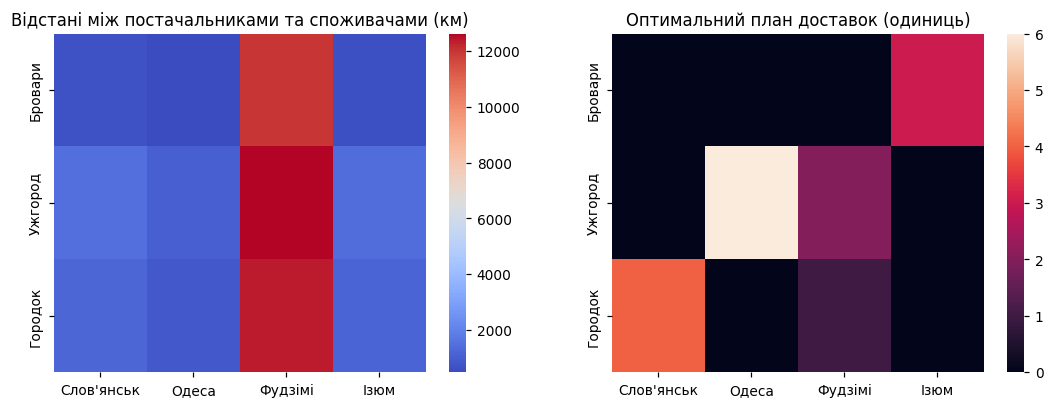

In [173]:
# ВАШ КОД
import seaborn as sns

D_plan = pd.DataFrame(
    D,
    index=постачальники,
    columns=споживачі,
)

fig, axs = plt.subplots(
    nrows=1, ncols=2,
    figsize=(12, 4)
)
axs[0].set_title("Відстані між постачальниками та споживачами (км)")
sns.heatmap(D_plan, cmap="coolwarm", ax=axs[0])
axs[1].set_title("Оптимальний план доставок (одиниць)")
sns.heatmap(X_plan, ax=axs[1])
plt.show()

**Висновок:** З першого графіку видно, що відстань до Фудзімі дуже збільшує межі, в порівнянні з іншими містами. На другому графіку бачимо з кольорами, де перевезень було найбільше та скільки саме (напр. Ужгород-Одеса аж 6, Городок-Фудзімі - 1, а всі чорні клітинки - по 0).

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [174]:
ІНСТРУМЕНТИ_ШІ = 'Gemini, Claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'ні',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'ні',
    'етапи 7–8, перевірка та цілочисельність': 'синтаксис',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'Завдання 5.2, добавлені AutoMinorLocator, MultipleLocator, а також дрібна сітка для чіткішого розуміння графіків.\n \
 У завданні 7 було проконсультовано, як це краще зробити\n \
 У завданні 10 код для pulp було згенеровано, але перевірено та виправлено відповідно до моєї версії pulp, щоб він працював коректно.\n'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [175]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Бугай Софія
інструменти:                               Gemini, Claude
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     ні
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             ні
етапи 7–8, перевірка та цілочисельність:   синтаксис
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Завдання 5.2, добавлені AutoMinorLocator, MultipleLocator, а також дрібна сітка для чіткішого розуміння графіків.
  У завданні 7 було проконсультовано, як це краще зробити
  У завданні 10 код для pulp було згенеровано, але перевірено та виправлено відповідно до моєї версії pulp, щоб він працював коректно.



---
# Крок 13. Фінальна самоперевірка

In [176]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
